In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
df = pd.read_csv("hourly_taxi_data.csv")

df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

df = df.set_index("pickup_datetime")

In [3]:
train = df[: "2025-11-23"]
test = df["2025-11-24":]

In [4]:
model = SARIMAX(
    train["trips"],
    order=(2,1,2),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

print(results.summary())

/Users/campbell/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/campbell/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            7     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.66908D+00    |proj g|=  5.51290D-01


 This problem is unconstrained.



At iterate    5    f=  7.27174D+00    |proj g|=  2.28071D-01

At iterate   10    f=  7.25683D+00    |proj g|=  7.41829D-02

At iterate   15    f=  7.25611D+00    |proj g|=  7.66228D-02

At iterate   20    f=  7.24923D+00    |proj g|=  1.23205D-01

At iterate   25    f=  7.24265D+00    |proj g|=  4.69606D-02

At iterate   30    f=  7.24250D+00    |proj g|=  7.85810D-04

At iterate   35    f=  7.24247D+00    |proj g|=  1.47769D-02

At iterate   40    f=  7.23843D+00    |proj g|=  1.17251D-01

At iterate   45    f=  7.23136D+00    |proj g|=  6.77160D-02

At iterate   50    f=  7.22464D+00    |proj g|=  6.71756D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

/Users/campbell/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                                trips   No. Observations:                 2020
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 24)   Log Likelihood              -14593.777
Date:                              Wed, 11 Mar 2026   AIC                          29201.555
Time:                                      17:08:44   BIC                          29240.648
Sample:                                           0   HQIC                         29215.921
                                             - 2020                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7169      0.072      9.993      0.000       0.576       0.858
ar.L2          0.08

In [5]:
forecast = results.forecast(len(test))

/Users/campbell/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/campbell/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


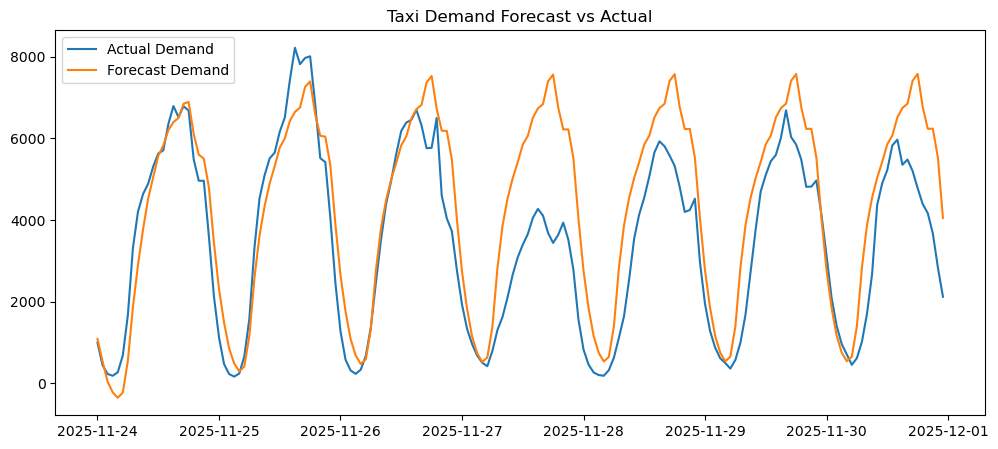

In [6]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test["trips"], label="Actual Demand")
plt.plot(test.index, forecast, label="Forecast Demand")

plt.title("Taxi Demand Forecast vs Actual")

plt.legend()

plt.savefig("forecast_vs_actual.png")

plt.show()